In [5]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Update projections onto decoder axes

Results of `scripts/pseudo_decoding/belief_partitions/decoder_update_projections.py`.

- For each (session, feature X) there are 8 pair splits. In each split, half of each chose-X cell (outcome x partition on trial k) are test trials k; k and k+1 are reserved; the remaining trials are axis trials.
- Split i's pref (High X vs. High Not X) and conf (High vs. Low) decoders are trained on split i's axis trials only, using the `*_99th_no_cond_window_filter_drift` units.
- Each test trial's change in pre-stimulus activity, x[k+1] - x[k], is projected per bin onto split i's axis and averaged over bins.

Each value is the mean, across (session, feature, split) units, of a cell's mean projection, with each (feature, split) axis scaled to unit length. Error bars are SE across units.

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "/data/patrick_res/decoder_update_projections/both_StimOnset"

def read(name):
    # return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_{name}.pickle"))
    # return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_axis_norm_{name}.pickle"))
    return pd.read_pickle(os.path.join(OUTPUT_DIR, f"decoder_updates_old_axes_{name}.pickle"))

stats = read("stats")
cells = read("cells")
events = read("events")

## Tests

One-sided sign-flip tests, flips per (session, feature, split). Each contrast is signed so the hypothesis predicts a positive value.

In [17]:
stats[["contrast", "axis", "plus", "minus", "mean_d", "n_units", "p"]].round(4)

,contrast,axis,plus,minus,mean_d,n_units,p
0,conf_cor,conf,cor/Low,cor/High,0.1838,2400,0.0001
1,conf_inc,conf,inc/Low,inc/High,0.2098,2400,0.0001
2,pref_cor,pref,cor/Low,cor/High X,0.0117,2256,0.0261
3,pref_inc,pref,inc/High Not X,inc/High X,0.0965,2189,0.0001


## Cell means

Chose-X test trials, by outcome and belief partition on trial k. For conf, High pools High X and High Not X.

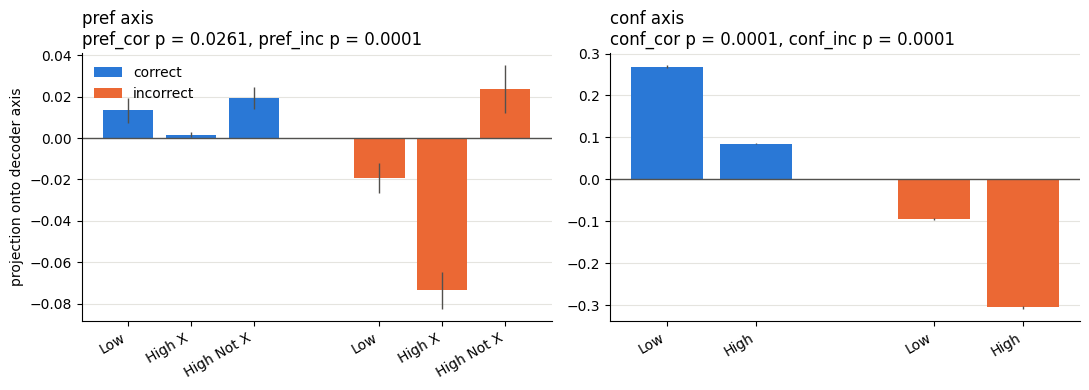

In [18]:
AXIS_PARTITIONS = {"pref": ["Low", "High X", "High Not X"], "conf": ["Low", "High"]}
# blue / orange rather than green / red: green / red fails the colorblind (deutan) separation check
OUTCOME_COLORS = {"cor": "#2a78d6", "inc": "#eb6834"}
OUTCOME_LABELS = {"cor": "correct", "inc": "incorrect"}

def plot_cells(ax, cells_df, axis_name, title):
    partitions = AXIS_PARTITIONS[axis_name]
    df = cells_df[cells_df.axis == axis_name].set_index("cell")
    for i, outcome in enumerate(["cor", "inc"]):
        x = np.arange(len(partitions)) + i * (len(partitions) + 1)
        rows = df.loc[[f"{outcome}/{p}" for p in partitions]]
        ax.bar(x, rows["mean"], yerr=rows["se"], width=0.8, color=OUTCOME_COLORS[outcome],
               linewidth=0, error_kw={"elinewidth": 1, "ecolor": "#52514e"},
               label=OUTCOME_LABELS[outcome])
    ticks = np.concatenate([np.arange(len(partitions)) + i * (len(partitions) + 1) for i in range(2)])
    ax.set_xticks(ticks)
    ax.set_xticklabels(partitions * 2, rotation=30, ha="right")
    ax.axhline(0, color="#52514e", linewidth=1)
    ax.grid(axis="y", color="#e5e4df", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)
    ax.set_title(title, loc="left")

def p_str(axis_name):
    s = stats[stats.axis == axis_name].set_index("contrast")
    return ", ".join(f"{c} p = {s.loc[c, 'p']:.4f}" for c in s.index)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, axis_name in zip(axes, ["pref", "conf"]):
    plot_cells(ax, cells, axis_name, f"{axis_name} axis\n{p_str(axis_name)}")
axes[0].set_ylabel("projection onto decoder axis")
axes[0].legend(frameon=False, loc="upper left")
fig.tight_layout()

## Counts

Test events per session, pooled over features, averaged over the 8 splits.

In [12]:
per_session = (events.groupby(["session", "split", "pref_cell"]).size()
               .unstack("pref_cell").fillna(0).groupby("session").mean())
order = [f"{o}/{p}" for o in ["cor", "inc"] for p in AXIS_PARTITIONS["pref"]]
pd.DataFrame({"median": per_session.median(), "min": per_session.min(),
              "sessions with 0": (per_session == 0).sum()}).loc[order]

,median,min,sessions with 0
pref_cell,,,
cor/Low,104.1875,14.000,0
cor/High X,100.8750,14.000,0
cor/High Not X,106.5625,9.250,0
inc/Low,109.1875,13.625,0
inc/High X,6.0000,0.625,0
inc/High Not X,82.5000,13.000,0
